# Производительность при N=10 000
Дополнительное задание 3: измеряется sir_run, а не создание модели,
сохранение CSV или построение графика. Каждый образец получает новую
активированную модель в setup. evals=1 исключает повторный запуск
уже завершённой модели внутри одного измерения.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

using BenchmarkTools

In [2]:
function fresh_model(N)
    I0=N÷100
    m=MakeSIRModel([N-I0,I0,0],BASE_P;seed=1234)
    activate(m)
end

fresh_model (generic function with 1 method)

In [3]:
rows=NamedTuple[]
samples=NamedTuple[]
for N in (1000,10000)
    sir_run(fresh_model(N),40.0) # прогрев компиляции вне измерения
    trial=@benchmark sir_run(m,40.0) setup=(m=fresh_model($N)) evals=1 samples=10 seconds=3600
    push!(rows,(;N,samples=length(trial),median_ms=median(trial).time/1e6,
        minimum_ms=minimum(trial).time/1e6,memory_bytes=median(trial).memory,
        allocations=median(trial).allocs))
    append!(samples,[(;N,sample=j,time_ms=t/1e6) for (j,t) in enumerate(trial.times)])
    model,result=simulate(family="benchmark",u0=[N-N÷100,N÷100,0])
    save_table("benchmark-model-N$(N)",DataFrame([result]))
end
summary=save_table("benchmark-summary",DataFrame(rows))
save_table("benchmark-samples",DataFrame(samples))
display(summary)

Row,N,samples,median_ms,minimum_ms,memory_bytes,allocations
,Int64,Int64,Float64,Float64,Int64,Int64
1,1000,10,141.636,139.351,113644784,4257812
2,10000,10,1836.21,1759.23,1172012704,44228347


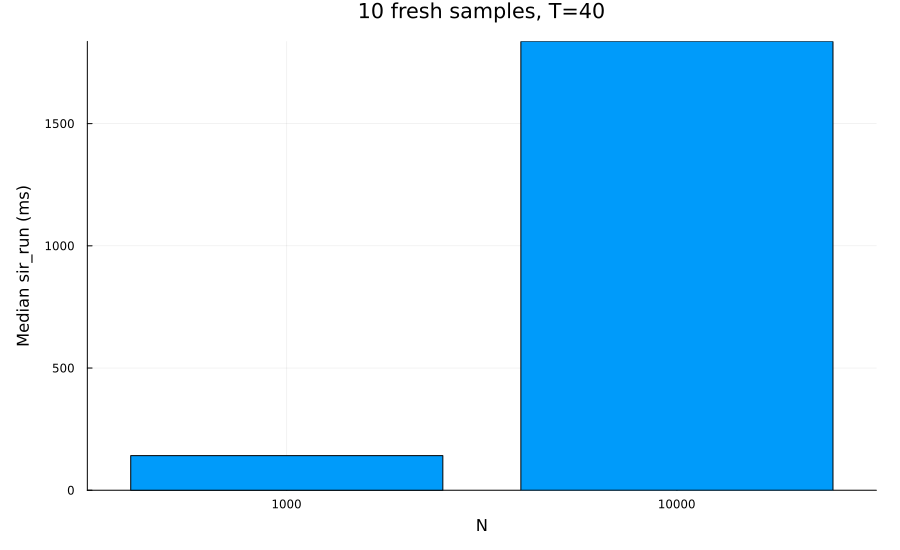

In [4]:
fig=bar(string.(summary.N),summary.median_ms;label=false,xlabel="N",
    ylabel="Median sir_run (ms)",title="10 fresh samples, T=40",size=(900,550))
savefig(fig,figure_path("06-plot"))
display(fig)

## Что определяет затраты
Очередь ConcurrentSim обрабатывает также контакты, не приведшие к заражению.
Поэтому число переходов S→I→R существенно меньше числа событий планировщика.
В реализации уже используются счётчики состояний O(1), столбцовые журналы
и O(1)-удаление умершего из списка с заменой последним элементом.
Дальнейшие варианты: разделить журнал и измерение процесса, предварительно
резервировать векторы, распараллеливать независимые повторы. Их ускорение
здесь не измерено. Агрегированный алгоритм заражений изменит сам способ DES.

In [5]:
scaling=summary.median_ms[2]/summary.median_ms[1]
display((population_ratio=10,time_ratio=scaling))

(population_ratio = 10, time_ratio = 12.96430780717439)